# Mini-lab: OT-CFM vs vanilla CFM (fill-in style)

**Goal:** understand and implement **minibatch Optimal-Transport Conditional Flow
Matching (OT-CFM)**, then compare it head-to-head against the vanilla CFM you
already built in `lab_four`.

This is a *fill-in* lab like `lab_four.ipynb`: find each
`raise NotImplementedError(...)` and fill it in. Every blank has a `# Step N:`
comment + a `# Hint:` with the exact tool/API to use (so you don't have to
hunt the docs).

## What you already know (from lab_four)

Vanilla CFM training, for one batch:
```python
z, c   = data.sample(b)                 # clean trajectory + boundary
eps    = randn_like(z)                  # RANDOM noise, independent of z
x_t    = α(t)·z + β(t)·eps              # point on the straight line eps→z
target = α̇·z + β̇·eps                    # the conditional velocity
loss   = || net(x_t, t, c) − target ||²
```

## The one idea this lab adds

Vanilla pairs each `z` with a **random** `eps`. OT-CFM instead pairs them so
each `z` gets a **nearby** `eps` (minimum total distance) — within the minibatch.
That's the *only* change. We'll see why it (sometimes) helps.

In [ ]:
# --- bootstrap ---
import os, sys
_cwd = os.path.abspath("")
_root = _cwd if os.path.basename(_cwd) != "flow" else os.path.dirname(_cwd)
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import torch
import matplotlib.pyplot as plt

from flow.lab_four_explore import (
    GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta,
    BurgersDataset, BurgersFlowTrainer, BurgersVectorField, BurgersEulerSampler,
    compute_J_and_energy, make_eval_batch, load_burgers_train,
    T_IDX,
)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

/opt/homebrew/Caskroom/miniconda/base/envs/diffphycon/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


/Users/baochen/diffphycon/diffusion/diffusion_1d_burgers.py:730: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


# Part 1 — First SEE the problem, then fix it (gradual, no algorithm to memorize)

We build intuition on 4 points in 1D before touching Burgers.
- data `z = [-1.0, -0.4, 0.4, 1.0]`
- noise `eps` = 4 random values

We'll go in 3 small steps:
- **1a** (provided) — look at what RANDOM pairing does (lines cross)
- **1b** (provided) — see what `linear_sum_assignment` does on a tiny example
  (so it's not a black box when you call it)
- **Q1** (you) — put the two together into `ot_pair`

## 1a. What RANDOM pairing looks like (provided — just run, no fill-in)

Vanilla CFM connects each noise `eps[i]` straight to data `z[i]`, using whatever
random `eps` it happened to draw. Run this and look: **the lines CROSS.** Those
crossings are exactly what make the learned flow curved (the network has to
average conflicting directions where lines cross).

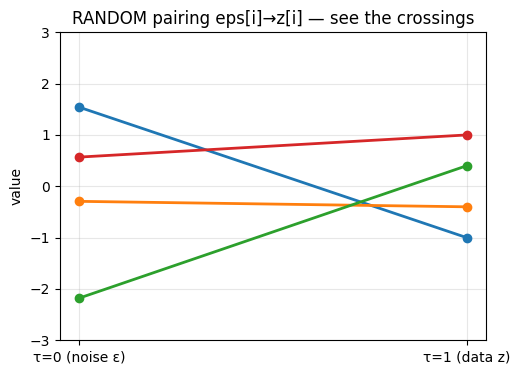

In [ ]:
def _viz_random_pairing():
    torch.manual_seed(0)
    z = torch.tensor([-1.0, -0.4, 0.4, 1.0])
    eps = torch.randn(4)
    fig, ax = plt.subplots(figsize=(5.5, 4))
    for i in range(4):
        ax.plot([0, 1], [eps[i].item(), z[i].item()], "-o", lw=2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["τ=0 (noise ε)", "τ=1 (data z)"])
    ax.set_title("RANDOM pairing eps[i]→z[i] — see the crossings")
    ax.grid(alpha=0.3); ax.set_ylim(-3, 3); ax.set_ylabel("value")
    plt.show()

_viz_random_pairing()

## 1b. What `linear_sum_assignment` does (provided — just run)

Finding the pairing with the LEAST total distance is a classic, solved problem
(the "assignment problem"). **You do NOT implement the algorithm** —
`scipy.optimize.linear_sum_assignment` does it for you. Here's *exactly* what it
does on a tiny 3×3 cost matrix, so it's not a black box when you call it below.

In [ ]:
from scipy.optimize import linear_sum_assignment

# cost[i, j] = how expensive to match row i to column j (you make this up here)
cost = np.array([[9, 1, 5],
                 [8, 7, 2],
                 [1, 6, 9]], dtype=float)

row, col = linear_sum_assignment(cost)
print("row =", row)                    # [0 1 2]  — always just 0..n-1
print("col =", col)                    # [1 2 0]  — col[k] = best column for row k
print("picked costs =", cost[row, col])# [1. 2. 1.]  one cheapest pick per row
print("total =", cost[row, col].sum()) # 4.0  — the MINIMUM possible total
# It chose: row0→col1 (1), row1→col2 (2), row2→col0 (1).  No greedy mistakes —
# it's globally optimal. That's all we need.

row = [0 1 2]
col = [1 2 0]
picked costs = [1. 2. 1.]
total = 4.0


## Question 1 — `ot_pair(z, eps)`  (now you have both pieces)

Goal: reorder `eps` so each `z[k]` is matched to a NEARBY `eps` (minimum total
distance). You just (1) build a cost matrix of distances between every `z` and
every `eps`, (2) call the solver you saw in 1b, (3) reorder `eps`.

**You are NOT writing the assignment algorithm** — just feeding it a cost matrix.

**3 fill-in Steps.**

In [ ]:
def ot_pair(z: torch.Tensor, eps: torch.Tensor) -> torch.Tensor:
    """Reorder `eps` along dim 0 to OT-match `z` (minibatch optimal transport).

    Args:
        z:   (b, ...) clean samples
        eps: (b, ...) noise, same shape as z
    Returns:
        eps_reordered: (b, ...) — a permutation of eps along dim 0, so eps[k] is
                       now matched to z[k].
    """
    # Step 1: Flatten each sample to a vector so we can measure distances between
    #         whole trajectories. z, eps are (b, ...); make them (b, D).
    #
    # Hint: tensor.flatten(start_dim=1) collapses all dims AFTER dim 0.
    #       z.flatten(1) turns (b, 2, 16, 128) into (b, 4096).
    #           z_flat   = z.flatten(1)
    #           eps_flat = eps.flatten(1)
    z_flat = z.flatten(1)
    eps_flat = eps.flatten(1)

    # Step 2: Build the (b, b) cost matrix: cost[i, j] = || z_i − eps_j ||²
    #
    # Hint: torch.cdist(A, B) returns the (b, b) matrix of euclidean (NOT squared)
    #       distances between rows of A and rows of B. Square it:
    #           cost = torch.cdist(z_flat, eps_flat) ** 2
    cost = torch.cdist(z_flat, eps_flat, p=2) ** 2

    # Step 3: Call the solver (exactly like 1b), then reorder eps with col.
    #
    # Hint:
    #     row, col = linear_sum_assignment(cost.detach().cpu().numpy())
    #     eps_reordered = eps[col]      # gather eps along dim 0 in the matched order
    #     return eps_reordered          # eps[col] stays on the original device
    row, col = linear_sum_assignment(cost.detach().cpu().numpy())
    eps_reordered = eps[col]
    return eps_reordered

## 1c. Compare random vs OT pairing (provided — run AFTER filling Q1)

Now the same 4 points, paired both ways. OT's lines should stop crossing, and
the total cost should drop.

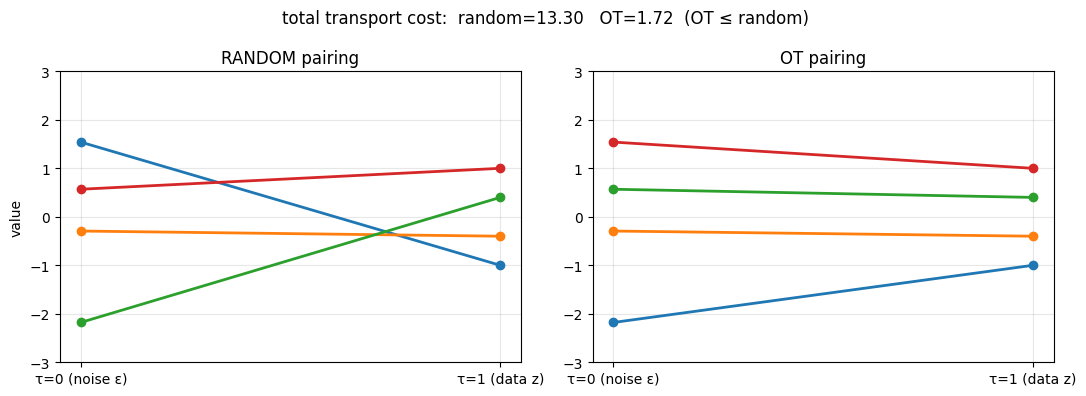

In [ ]:
def _viz_compare_pairing():
    torch.manual_seed(0)
    z = torch.tensor([-1.0, -0.4, 0.4, 1.0])
    eps = torch.randn(4)
    eps_ot = ot_pair(z.view(4, 1), eps.view(4, 1)).view(4)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (title, e) in zip(axes, [("RANDOM pairing", eps), ("OT pairing", eps_ot)]):
        for i in range(4):
            ax.plot([0, 1], [e[i].item(), z[i].item()], "-o", lw=2)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["τ=0 (noise ε)", "τ=1 (data z)"])
        ax.set_title(title); ax.grid(alpha=0.3); ax.set_ylim(-3, 3)
    total_rand = ((z - eps) ** 2).sum().item()
    total_ot   = ((z - eps_ot) ** 2).sum().item()
    axes[0].set_ylabel("value")
    fig.suptitle(f"total transport cost:  random={total_rand:.2f}   OT={total_ot:.2f}  (OT ≤ random)")
    plt.tight_layout()
    plt.show()

_viz_compare_pairing()   # ← uncomment and run after filling Q1

# Part 2 — OT-CFM trainer (fill-in)

Now plug `ot_pair` into the training loss. Recall the vanilla
`BurgersFlowTrainer.get_train_loss` (from lab_four) samples `eps` *inside*
`path.sample_conditional_path`. To control the pairing we instead sample `eps`
ourselves, OT-reorder it, then build `x_t` by hand.

## Question 2 — `OTBurgersFlowTrainer.get_train_loss`

Same as vanilla, but:
  (1) sample `eps` yourself,
  (2) `eps = ot_pair(z, eps)`,
  (3) build `x_t = α(t)·z + β(t)·eps` by hand,
  (4) rest is identical (target velocity + inpaint trick + MSE).

**5 fill-in Steps.**

In [ ]:
class OTBurgersFlowTrainer(BurgersFlowTrainer):
    """Vanilla BurgersFlowTrainer + minibatch-OT pairing of (z, eps)."""

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: sample a batch (z, c) from self.data  (same as vanilla)
        #
        # Hint: z, c = self.data.sample(batch_size)
        z, c = self.data.sample(batch_size)

        # Step 2: sample eps ~ N(0, I) with the SAME shape as z, then OT-reorder it.
        #
        # Hint:
        #     eps = torch.randn_like(z)
        #     eps = ot_pair(z, eps)        # ← the whole point of this lab
        eps = torch.randn_like(z)
        eps = ot_pair(z, eps)
        

        # Step 3: sample FM time t ~ U[0,1], shape (b, 1, 1, 1) to broadcast over z.
        #
        # Hint: t = torch.rand(batch_size, 1, 1, 1, device=z.device)
        t = torch.rand(batch_size, 1, 1, 1, device=z.device)

        # Step 4: build x_t = α(t)·z + β(t)·eps  BY HAND (don't call
        #         sample_conditional_path — it would draw its own random eps).
        #         Then get the target velocity using the SAME eps.
        #
        # Hint: the path object exposes the schedules as callables:
        #     alpha_t = self.path.alpha(t)     # = t        (LinearAlpha)
        #     beta_t  = self.path.beta(t)      # = 1 - t     (LinearBeta)
        #     x_t = alpha_t * z + beta_t * eps
        #     u_target = self.path.target_velocity(x_t, z, t, eps)   # Form A uses eps
        alpha_t = self.path.alpha(t)
        beta_t = self.path.beta(t)
        
        x_t = alpha_t * z + beta_t * eps
        u_target = self.path.target_velocity(x_t, z, t, eps)

        # Step 5: apply the inpaint trick (zero target velocity at boundary rows),
        #         forward through self.net, return MSE — identical to vanilla.
        #
        # Hint:
        #     u_target[:, 0, 0, :]     = 0
        #     u_target[:, 0, T_IDX, :] = 0
        #     u_pred = self.net(x_t, t, c)
        #     return ((u_pred - u_target) ** 2).mean()
        u_target[:, 0, 0, :] = 0
        u_target[:, 0, T_IDX, :] = 0
        u_pred = self.net(x_t, t, c)
        return ((u_pred - u_target) ** 2).mean()

# Part 3 — Train vanilla vs OT (small scale) and compare

Train two fresh nets for 3000 steps each on the SAME data, one with the vanilla
trainer, one with OT-CFM. Then evaluate J on the held-out test batch.

(~5-10 min total on M4 Pro.)

In [ ]:
import os

CKPT_DIR = os.path.join(_root, "flow", "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)


def train_one(
    trainer_cls, num_steps=3000, lr=1e-3, seed=0, dataset=None, save_path=None):
    """Train a fresh net. If save_path exists → load it and SKIP
    training."""
    torch.manual_seed(seed)
    ds = BurgersDataset(dataset, device=device)
    path = GaussianConditionalProbabilityPath(LinearAlpha(), LinearBeta())
    net = BurgersVectorField(dim=64, dim_mults=(1, 2, 4, 8)).to(device)
    trainer = trainer_cls(net, path, ds, lr=lr)

    # 如果 checkpoint 已存在 → 直接加载,跳过训练(秒回)
    if save_path and os.path.isfile(save_path):
        ckpt = torch.load(save_path, map_location=device, weights_only=False)
        net.load_state_dict(ckpt["state_dict"])
        net.eval()
        trainer.loss_history = ckpt.get("loss_history", [])
        print(f"  ✅ loaded {save_path} (skip training)")
        return net, trainer

    # 否则训练 + 存盘
    trainer.train(num_steps=num_steps, batch_size=64, print_every=200)
    if save_path:
        torch.save(
            {"state_dict": net.state_dict(), "loss_history": trainer.loss_history},
            save_path,
        )
        print(f"  💾 saved {save_path}")
    return net, trainer


# load training data ONCE
train_raw = load_burgers_train(device=device, dataset="free_u_f_1e4_front_rear_quarter")

print("=== VANILLA CFM ===")
net_vanilla, tr_vanilla = train_one(
    BurgersFlowTrainer,
    num_steps=3000,
    dataset=train_raw,
    save_path=os.path.join(CKPT_DIR, "otcfm_vanilla_3k.pt"),
)
print("=== OT-CFM ===")
net_ot, tr_ot = train_one(
    OTBurgersFlowTrainer,
    num_steps=3000,
    dataset=train_raw,
    save_path=os.path.join(CKPT_DIR, "otcfm_ot_3k.pt"),
)

Load dataset /Users/baochen/diffphycon/data/free_u_f_1e4_front_rear_quarter/burgers_train.h5
=== VANILLA CFM ===
  ✅ loaded /Users/baochen/diffphycon/flow/checkpoints/otcfm_vanilla_3k.pt (skip training)
=== OT-CFM ===
  ✅ loaded /Users/baochen/diffphycon/flow/checkpoints/otcfm_ot_3k.pt (skip training)


### Loss curves side by side (provided)

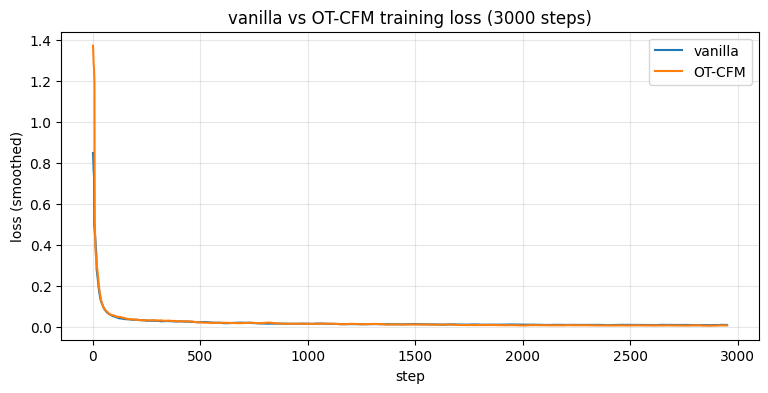

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, tr in [("vanilla", tr_vanilla), ("OT-CFM", tr_ot)]:
    h = np.array(tr.loss_history)
    sm = np.convolve(h, np.ones(50) / 50, mode="valid")
    ax.plot(sm, label=name)
ax.set_xlabel("step"); ax.set_ylabel("loss (smoothed)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("vanilla vs OT-CFM training loss (3000 steps)")
plt.show()

## Question 3 — evaluate J for both on the held-out test batch

**2 fill-in Steps.**

In [ ]:
c_test = make_eval_batch(n=80, split="test", device=device)   # held-out test

# Step 1: for each net, sample with BurgersEulerSampler(net, n_steps=100) on c_test,
#         then compute J/E with compute_J_and_energy.
#
# Hint:
#     sampler = BurgersEulerSampler(net_vanilla, n_steps=100)
#     x = sampler.sample(c_test)
#     J_v, E_v = compute_J_and_energy(x, c_test)
#   ... and the same for net_ot.
sampler = BurgersEulerSampler(net_vanilla, n_steps=100)
x = sampler.sample(c_test)
J_v, E_v = compute_J_and_energy(x, c_test)
print(f'vanilla:    J={J_v:.5f}    E={E_v:.1f}')

sampler = BurgersEulerSampler(net_ot, n_steps=100)
x = sampler.sample(c_test)
J_v, E_v = compute_J_and_energy(x, c_test)
print(f'OT-CFM:    J={J_v:.5f}    E={E_v:.1f}')
# Step 2: print both, side by side.
#
# Hint:
#     print(f'vanilla:  J={J_v:.5f}  E={E_v:.1f}')
#     print(f'OT-CFM :  J={J_o:.5f}  E={E_o:.1f}')


Load dataset /Users/baochen/diffphycon/data/free_u_f_1e4_front_rear_quarter/burgers_test.h5


/Users/baochen/diffphycon/dataset/apps/burgers_h5py.py:124: UserWarning: 'makedirs' is deprecated, use 'os.makedirs(path, exist_ok=True)' instead
  makedirs(self.processed_dir)
100%|██████████| 10000/10000 [00:09<00:00, 1040.05it/s]


vanilla:    J=0.19657    E=898.9


100%|██████████| 10000/10000 [00:09<00:00, 1097.07it/s]


OT-CFM:    J=0.16806    E=635.1


In [ ]:
c_test = make_eval_batch(n=8, split="test", device=device)   # held-out test

# Step 1: for each net, sample with BurgersEulerSampler(net, n_steps=100) on c_test,
#         then compute J/E with compute_J_and_energy.
#
# Hint:
#     sampler = BurgersEulerSampler(net_vanilla, n_steps=100)
#     x = sampler.sample(c_test)
#     J_v, E_v = compute_J_and_energy(x, c_test)
#   ... and the same for net_ot.
sampler = BurgersEulerSampler(net_vanilla, n_steps=100)
x = sampler.sample(c_test)
J_v, E_v = compute_J_and_energy(x, c_test)
print(f'vanilla:    J={J_v:.5f}    E={E_v:.1f}')

sampler = BurgersEulerSampler(net_ot, n_steps=100)
x = sampler.sample(c_test)
J_v, E_v = compute_J_and_energy(x, c_test)
print(f'OT-CFM:    J={J_v:.5f}    E={E_v:.1f}')
# Step 2: print both, side by side.
#
# Hint:
#     print(f'vanilla:  J={J_v:.5f}  E={E_v:.1f}')
#     print(f'OT-CFM :  J={J_o:.5f}  E={E_o:.1f}')


Load dataset /Users/baochen/diffphycon/data/free_u_f_1e4_front_rear_quarter/burgers_test.h5


100%|██████████| 10000/10000 [00:01<00:00, 7896.21it/s]


vanilla:    J=0.13012    E=704.9


100%|██████████| 10000/10000 [00:01<00:00, 7889.53it/s]

OT-CFM:    J=0.19427    E=589.4


# Part 4 — Straightness diagnostic: few-step robustness (fill-in)

**The practical payoff of OT-CFM is straighter ODE paths.** A straight path can
be integrated accurately with FEW Euler steps. So: if OT really straightens the
flow, then OT's J at `n_steps=2` should be CLOSER to its `n_steps=100` J than
vanilla's is.

We sweep `n_steps ∈ {2, 4, 8, 100}` for both nets and watch the J gap.

## Question 4 — few-step sweep

**2 fill-in Steps.**

Load dataset /Users/baochen/diffphycon/data/free_u_f_1e4_front_rear_quarter/burgers_test.h5


100%|██████████| 10000/10000 [00:01<00:00, 7832.34it/s]


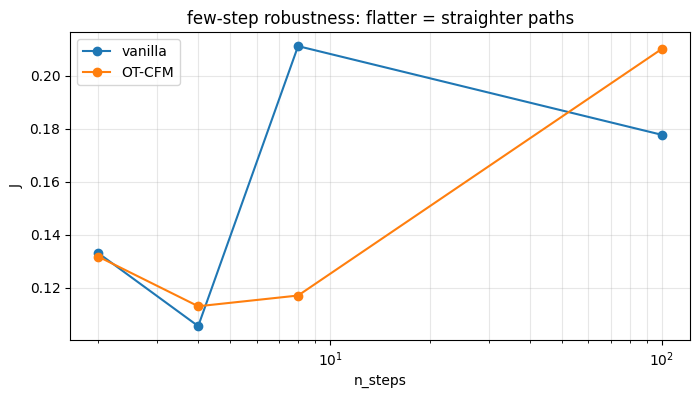

In [ ]:
N_STEPS_LIST = [2, 4, 8, 100]
c_test = make_eval_batch(n=8, split="test", device=device)   # held-out test
# Step 1: for each net (vanilla, OT), and each n in N_STEPS_LIST, sample and
#         compute J. Collect into a dict {name: {n: J}}.
#
# Hint:
#     results = {}
#     for name, net in [("vanilla", net_vanilla), ("OT-CFM", net_ot)]:
#         results[name] = {}
#         for n in N_STEPS_LIST:
#             x = BurgersEulerSampler(net, n_steps=n).sample(c_test)
#             J, _ = compute_J_and_energy(x, c_test)
#             results[name][n] = J
results = {}
for name, net in [("vanilla", net_vanilla), ("OT-CFM", net_ot)]:
    results[name] = {}
    for n in N_STEPS_LIST:
        x = BurgersEulerSampler(net, n_steps=n).sample(c_test)
        J, _ = compute_J_and_energy(x, c_test)
        results[name][n] = J


# Step 2: plot J vs n_steps for both (log-x is nice since steps span 2..100).
#
# Hint:
#     fig, ax = plt.subplots(figsize=(8,4))
#     for name in results:
#         ax.plot(N_STEPS_LIST, [results[name][n] for n in N_STEPS_LIST], "o-", label=name)
#     ax.set_xscale("log"); ax.set_xlabel("n_steps"); ax.set_ylabel("J")
#     ax.legend(); ax.grid(alpha=0.3, which="both")
#     ax.set_title("few-step robustness: flatter = straighter paths")
#     plt.show()
fix, ax = plt.subplots(figsize=(8,4))
for name in results:
    ax.plot(N_STEPS_LIST, [results[name][n] for n in N_STEPS_LIST], "o-", label=name)
ax.set_xscale("log")
ax.set_xlabel("n_steps")
ax.set_ylabel("J")
ax.legend()
ax.grid(alpha=0.3, which="both")
ax.set_title("few-step robustness: flatter = straighter paths")
plt.show()

# Part 5 — Verdict (read after running)

Things to look for, and the honest expectations:

1. **Loss curve (Part 3):** OT's training loss often drops a bit faster / lower —
   the regression target has lower variance when pairs are OT-matched.

2. **J at n_steps=100 (Q3):** may be similar to vanilla. On this **strongly
   conditioned + inpainted** problem, OT's benefit is often **small** — the
   boundary `c` already constrains the output, so random pairing wasn't that bad.
   (This is itself an interesting, honest finding — OT-CFM's big wins are on
   *unconditional* generation.)

3. **Few-step gap (Q4):** the clearest place to see OT help. If OT's curve is
   FLATTER (J at n=2 close to J at n=100), its paths are straighter → you could
   sample in far fewer steps. Vanilla usually degrades more at n=2.

**Bottom line you're testing:** does OT-CFM buy us anything *here*? Maybe a little
(faster loss, flatter few-step curve), maybe not much on J. Either way you now
(a) understand OT pairing, (b) have implemented it, (c) measured it honestly.